--- 1. 数据加载与预处理 ---
数据集加载成功，形状为: (3959, 5)
添加偏置项后特征矩阵X_b的形状: (3959, 5)
训练集X_train形状: (3000, 5), y_train形状: (3000, 1)
测试集X_test形状: (959, 5), y_test形状: (959, 1)

--- 2. 批量梯度下降线性回归训练 ---
初始模型参数theta的形状: (5, 1)
开始训练，学习率: 0.0001, 迭代次数: 50000
迭代 5000/50000, 代价: 0.7992
迭代 10000/50000, 代价: 0.5647
迭代 15000/50000, 代价: 0.4687
迭代 20000/50000, 代价: 0.4266
迭代 25000/50000, 代价: 0.4072
迭代 30000/50000, 代价: 0.3978
迭代 35000/50000, 代价: 0.3930
迭代 40000/50000, 代价: 0.3904
迭代 45000/50000, 代价: 0.3889
迭代 50000/50000, 代价: 0.3879

训练完成！
最终模型参数theta:
[[ 0.17303221]
 [-0.00648451]
 [ 0.58242555]
 [ 0.15327203]
 [ 0.25447025]]

--- 3. 绘制均方误差代价函数曲线 ---


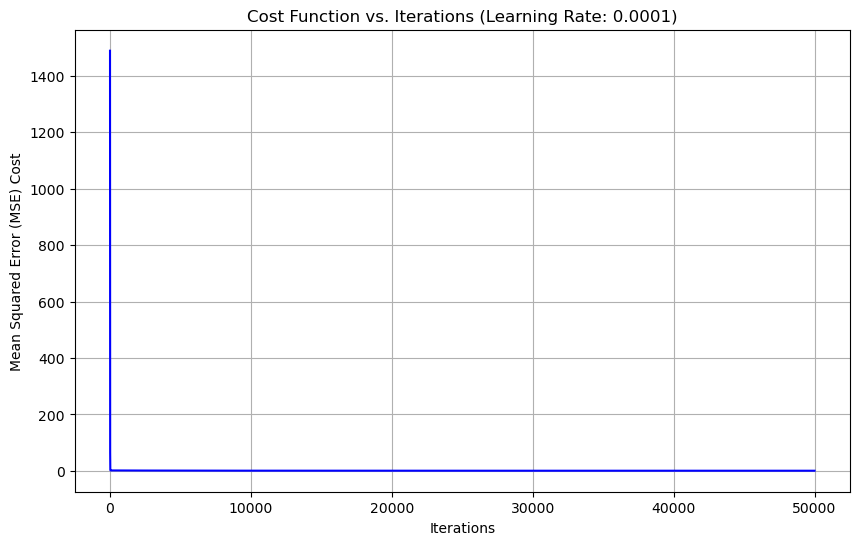


--- 4. 模型评估 (可选) ---
测试集上的均方误差 (MSE): 0.4456


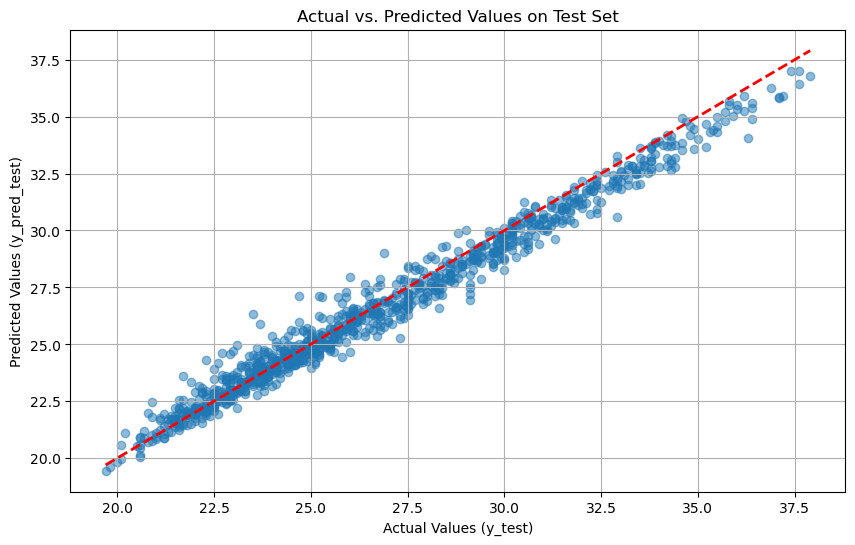


--- 5. 改变学习率并重新运行 ---
你可以尝试修改代码中的 `learning_rate` 值，例如：
  - `learning_rate = 0.001` (更高)
  - `learning_rate = 0.00001` (更低)
观察代价函数曲线如何变化，以及模型收敛的速度和效果。
如果学习率过高，代价函数可能会发散（值不断增大或变为NaN）。
如果学习率过低，模型收敛会非常缓慢。


In [1]:
# Textbook: Principles and Practices of Machine Learning
# Experiment 2-1: Linear Regression with Batch Gradient Descent
# Author: Zhe Chen (ml_iot@163.com), 2021 (Modified by ChatGPT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 解决中文显示问题 (已将所有中文标签替换为英文，所以此处无需特殊字体配置) ---
# 请确保以下两行代码被注释掉或删除，否则Matplotlib会尝试寻找这些字体
# plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'SimHei', 'sans-serif']
# plt.rcParams['axes.unicode_minus'] = False
# ----------------------------------------------------------------------------------

# --- 1. 数据加载与预处理 ---
print("--- 1. 数据加载与预处理 ---")
# load dataset
try:
    df = pd.read_csv('temperature_dataset.csv')
    data = np.array(df)
    print(f"数据集加载成功，形状为: {data.shape}")
except FileNotFoundError:
    print("错误：未找到 'temperature_dataset.csv' 文件。")
    print("请确保该文件与Python脚本在同一目录下，并包含至少5列温度数据。")
    print("你可以使用以下代码生成一个示例文件：")
    print("""
import numpy as np
import pandas as pd
np.random.seed(42)
# 生成3960行，5列的随机温度数据 (15到25度之间)
data_gen = np.random.rand(3960, 5) * 10 + 15 
df_gen = pd.DataFrame(data_gen, columns=[f'temp_sensor_{i+1}' for i in range(5)])
df_gen.to_csv('temperature_dataset.csv', index=False)
print('已生成示例文件 temperature_dataset.csv')
    """)
    exit() # 退出程序

# 划分特征 (X) 和标签 (y)
# 提示：将传感器2-5作为4维输入特征(X)
# 提示：将传感器1作为标签(y)
X = data[:, 1:5]  # 索引1,2,3,4对应第2-5列
y = data[:, 0]    # 索引0对应第1列

# 确保y是列向量
y = y.reshape(-1, 1)

# 为特征矩阵X添加偏置项
# 在X的第一列添加一列1，对应截距项theta_0
X_b = np.c_[np.ones((X.shape[0], 1)), X]
print(f"添加偏置项后特征矩阵X_b的形状: {X_b.shape}")

# 划分为训练集和测试集
# 提示：前3000个样本用于训练，剩余960个用于测试
train_size = 3000
test_size = 960

X_train = X_b[:train_size]
y_train = y[:train_size]
X_test = X_b[train_size:train_size + test_size]
y_test = y[train_size:train_size + test_size]

print(f"训练集X_train形状: {X_train.shape}, y_train形状: {y_train.shape}")
print(f"测试集X_test形状: {X_test.shape}, y_test形状: {y_test.shape}")

# --- 2. 批量梯度下降线性回归训练 ---
print("\n--- 2. 批量梯度下降线性回归训练 ---")

# 初始化模型参数
# X_train的形状是(样本数, 特征数+1)，所以theta的形状应该是(特征数+1, 1)
n_features = X_train.shape[1]
theta = np.random.randn(n_features, 1) # 随机初始化theta
print(f"初始模型参数theta的形状: {theta.shape}")

# 设置梯度下降参数
learning_rate = 0.0001 # 提示：学习率可设置为0.0001
n_iterations = 50000   # 迭代次数，可根据收敛情况调整
m = len(y_train)       # 训练样本数量

# 存储代价函数值用于绘图
cost_history = []

print(f"开始训练，学习率: {learning_rate}, 迭代次数: {n_iterations}")

for iteration in range(n_iterations):
    # 计算预测值
    predictions = X_train @ theta

    # 计算误差
    errors = predictions - y_train

    # 计算梯度
    # 梯度下降的矩阵形式：(1/m) * X_train.T @ errors
    gradients = (1/m) * X_train.T @ errors

    # 更新模型参数theta
    theta = theta - learning_rate * gradients

    # 计算当前迭代的均方误差(MSE)代价函数值
    # J(theta) = 1/(2m) * sum(errors^2)
    cost = (1/(2*m)) * np.sum(errors**2)
    cost_history.append(cost)

    if (iteration + 1) % (n_iterations / 10) == 0:
        print(f"迭代 {iteration + 1}/{n_iterations}, 代价: {cost:.4f}")

print("\n训练完成！")
print("最终模型参数theta:")
print(theta)

# --- 3. 绘制均方误差代价函数曲线 ---
print("\n--- 3. 绘制均方误差代价函数曲线 ---")

plt.figure(figsize=(10, 6))
plt.plot(range(n_iterations), cost_history, color='blue', linestyle='-')
plt.xlabel('Iterations') # 英文
plt.ylabel('Mean Squared Error (MSE) Cost') # 英文
plt.title(f'Cost Function vs. Iterations (Learning Rate: {learning_rate})') # 英文
plt.grid(True)
plt.show()

# --- 4. 模型评估 (可选) ---
print("\n--- 4. 模型评估 (可选) ---")
# 在测试集上评估模型性能
y_pred_test = X_test @ theta
test_mse = np.mean((y_pred_test - y_test)**2)
print(f"测试集上的均方误差 (MSE): {test_mse:.4f}")

# 绘制预测值与实际值
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 对角线
plt.xlabel('Actual Values (y_test)') # 英文
plt.ylabel('Predicted Values (y_pred_test)') # 英文
plt.title('Actual vs. Predicted Values on Test Set') # 英文
plt.grid(True)
plt.show()

# --- 5. 改变学习率并重新运行 ---
print("\n--- 5. 改变学习率并重新运行 ---")
print("你可以尝试修改代码中的 `learning_rate` 值，例如：")
print("  - `learning_rate = 0.001` (更高)")
print("  - `learning_rate = 0.00001` (更低)")
print("观察代价函数曲线如何变化，以及模型收敛的速度和效果。")
print("如果学习率过高，代价函数可能会发散（值不断增大或变为NaN）。")
print("如果学习率过低，模型收敛会非常缓慢。")